# Sampling testing

This notebook is created for sanity check of the DDPM/DDIM algorithms.

There are some generated samples, comparisons and checks.

## Imports & Device

In [6]:
import torch
import matplotlib.pyplot as plt

from prepare_dataset import PairedCIFAR10

from scripts.unet import UNet
from scripts.blocks import ResBlock, ScaleShiftResBlock
from scripts.model import (
    ConditionalDenoiser,
    ConditionalDenoiserConcat,
)
from scripts.diffusion import DDPM
from scripts.samplers import (
    ddpm_sample_respaced,
    ddim_sample,
)

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


## Configs

In [8]:
CHECKPOINT_FOLDER = "/path/to/checkpoints/"
MODEL_VARIANT = "add_add"
CHECKPOINT_PATH = CHECKPOINT_FOLDER + MODEL_VARIANT + "/best_model.pt"

NUM_SAMPLES = 8
NUM_STEPS = 50
ETA = 0.0

## Load the test set

In [9]:
test_dataset = PairedCIFAR10("test")

print("Test samples:", len(test_dataset))

image, cond, label = test_dataset[0]

print("Image:", image.shape)
print("Condition:", cond.shape)
print("Label:", label)

Test samples: 10000
Image: torch.Size([3, 32, 32])
Condition: torch.Size([16])
Label: tensor(3)


## Checkpoint & architecture

In [10]:
# Check the keys in case I forget how I saved them at the start :)
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'val_loss', 'cond_mean', 'cond_std'])


In [11]:
# Re-use this function instead of manually creating the architecture for each experiment (4)
def build_model(variant, device):
    if variant == "add_add":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ResBlock,
        )

        model = ConditionalDenoiser(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "concat_add":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ResBlock,
        )

        model = ConditionalDenoiserConcat(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "add_scale_shift":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ScaleShiftResBlock,
        )

        model = ConditionalDenoiser(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "concat_scale_shift":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ScaleShiftResBlock,
        )

        model = ConditionalDenoiserConcat(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    else:
        raise ValueError(
            f"Unknown model variant: {variant}"
        )

    # And send in to the device from here
    return model.to(device)

## Model

In [12]:
# Create the model based on the given architecture
model = build_model(
    MODEL_VARIANT,
    device,
)

# And load the weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

ConditionalDenoiser(
  (unet): UNet(
    (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (enc1): ResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj): Linear(in_features=256, out_features=64, bias=True)
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (skip): Identity()
    )
    (down1): Downsample(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (enc2): ResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj): Linear(in_features=256, out_features=128, bias=True)
      (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [13]:
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Parameters: {num_params / 1e6:.2f}M")

Parameters: 9.22M


## Condition normalization

In [14]:
cond_mean = checkpoint["cond_mean"].to(device)
cond_std = checkpoint["cond_std"].to(device)

print(cond_mean.shape)
print(cond_std.shape)

torch.Size([16])
torch.Size([16])


## Testing

In [15]:
images = []
conditions = []
labels = []

for i in range(NUM_SAMPLES):
    image, cond, label = test_dataset[i]

    images.append(image)
    conditions.append(cond)
    labels.append(label)

images = torch.stack(images).to(device)
conditions = torch.stack(conditions).to(device)
labels = torch.tensor(labels)

In [16]:
conditions_norm = (
    conditions - cond_mean
) / (cond_std + 1e-8)

In [17]:
ddpm = DDPM(
    timesteps=1000,
    schedule="cosine",
    device=device,
)

In [18]:
torch.manual_seed(42)

x_init = torch.randn(
    NUM_SAMPLES,
    3,
    32,
    32,
    device=device,
)

## DDPM

In [19]:
ddpm_samples = ddpm_sample_respaced(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=NUM_STEPS,
    x_init=x_init,
)

In [20]:
print(ddpm_samples.shape)

print(
    "min:",
    ddpm_samples.min().item(),
    "max:",
    ddpm_samples.max().item(),
)

torch.Size([8, 3, 32, 32])
min: -1.0 max: 1.0


## DDIM

In [21]:
ddim_samples = ddim_sample(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=NUM_STEPS,
    eta=ETA,
    x_init=x_init,
)

In [22]:
print(ddim_samples.shape)

print(
    "min:",
    ddim_samples.min().item(),
    "max:",
    ddim_samples.max().item(),
)

torch.Size([8, 3, 32, 32])
min: -1.0 max: 1.0


## Checks

In [23]:
def to_display(x):
    x = x.detach().cpu()

    x = (x + 1.0) / 2.0
    x = x.clamp(0.0, 1.0)

    return x.permute(1, 2, 0)

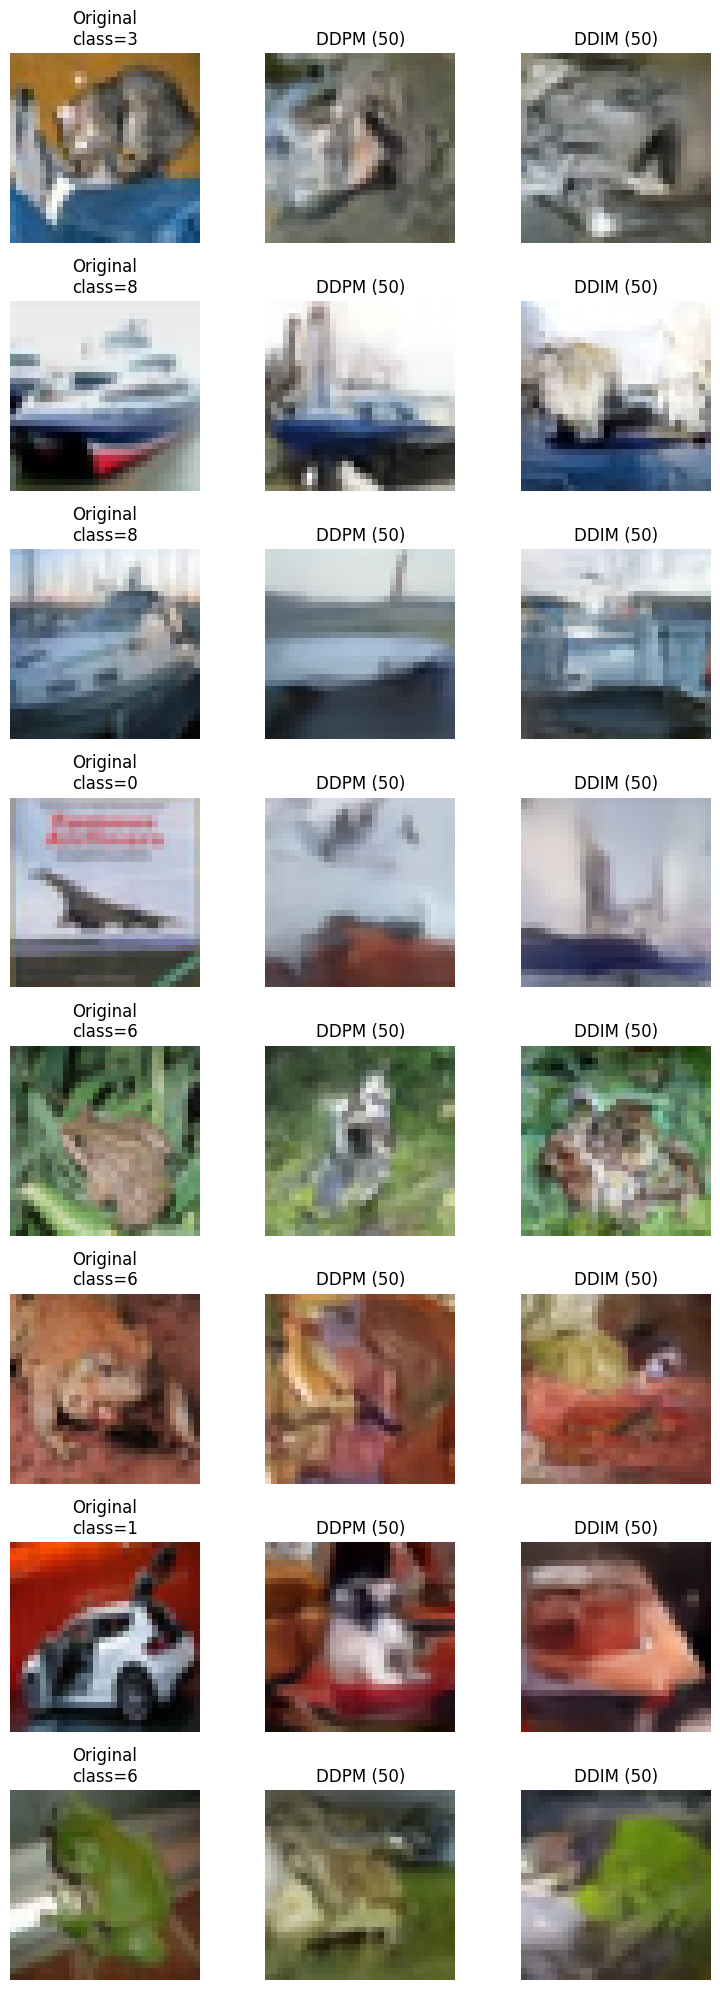

In [24]:
fig, axes = plt.subplots(
    NUM_SAMPLES,
    3,
    figsize=(8, 2.5 * NUM_SAMPLES),
)

for i in range(NUM_SAMPLES):

    axes[i, 0].imshow(
        to_display(images[i])
    )
    axes[i, 0].set_title(
        f"Original\nclass={labels[i].item()}"
    )

    axes[i, 1].imshow(
        to_display(ddpm_samples[i])
    )
    axes[i, 1].set_title(
        f"DDPM ({NUM_STEPS})"
    )

    axes[i, 2].imshow(
        to_display(ddim_samples[i])
    )
    axes[i, 2].set_title(
        f"DDIM ({NUM_STEPS})"
    )

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

## DDIM deterministic check

In [25]:
ddim_run_1 = ddim_sample(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=50,
    eta=0.0,
    x_init=x_init,
)

ddim_run_2 = ddim_sample(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=50,
    eta=0.0,
    x_init=x_init,
)

max_difference = (
    ddim_run_1 - ddim_run_2
).abs().max()

print(
    "Maximum difference:",
    max_difference.item()
)

Maximum difference: 0.0


With eta = 0, DDIM introduces no additional Gaussian noise during the reverse trajectory. Therefore, for fixed model weights, conditioning vector, initial noise x_T, and timestep schedule, the generated output is deterministic.

## DDPM Stochsticity

In [26]:
ddpm_run_1 = ddpm_sample_respaced(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=50,
    x_init=x_init,
)

ddpm_run_2 = ddpm_sample_respaced(
    model=model,
    ddpm=ddpm,
    cond=conditions_norm,
    num_steps=50,
    x_init=x_init,
)

difference = (
    ddpm_run_1 - ddpm_run_2
).abs().mean()

print(
    "Mean DDPM difference:",
    difference.item()
)

Mean DDPM difference: 0.2606485188007355
